LAB 2, TASK


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [2]:
np.random.seed(42)

In [3]:
data = pd.read_csv("fire_risk_train.csv")
data

,temperature_C,humidity_percent,wind_speed_kmph,air_quality_index,vegetation_index,emergency_response_time_min,fire_risk_score,fire_risk_level,random_noise
0,19.939478,14.613031,3.309713,51.580079,0.882388,2.426881,36.298824,Low,-1.349549
1,18.871172,45.988347,2.928750,54.831865,0.661799,3.573987,41.477312,Medium,-0.042336
2,20.003489,10.000000,1.009550,62.969945,0.348045,2.022868,39.487676,Low,-1.128474
3,17.908171,65.904458,3.521618,52.246847,0.400091,2.932591,43.355859,Medium,0.113624
4,28.292721,30.808170,4.020409,52.858654,0.403075,2.334457,55.468398,Medium,0.264644
...,...,...,...,...,...,...,...,...,...
235,29.751538,51.999129,3.421227,60.536824,0.095922,3.067803,33.931698,Low,-0.503421
236,21.691068,72.159161,1.704867,70.251426,0.658480,2.186454,42.633949,Medium,-1.376730
237,35.281036,34.525709,2.206417,60.448092,0.290198,3.966357,24.272872,Low,0.801164
238,21.996807,31.834259,0.583387,61.509936,0.527731,2.375698,27.089659,Low,0.069548


In [4]:
print('Missing Values:\n', data.isnull().sum())
print('\nDuplicates:', data.duplicated().sum())

Missing Values:
 temperature_C                  0
humidity_percent               0
wind_speed_kmph                0
air_quality_index              0
vegetation_index               0
emergency_response_time_min    0
fire_risk_score                0
fire_risk_level                0
random_noise                   0
dtype: int64

Duplicates: 0


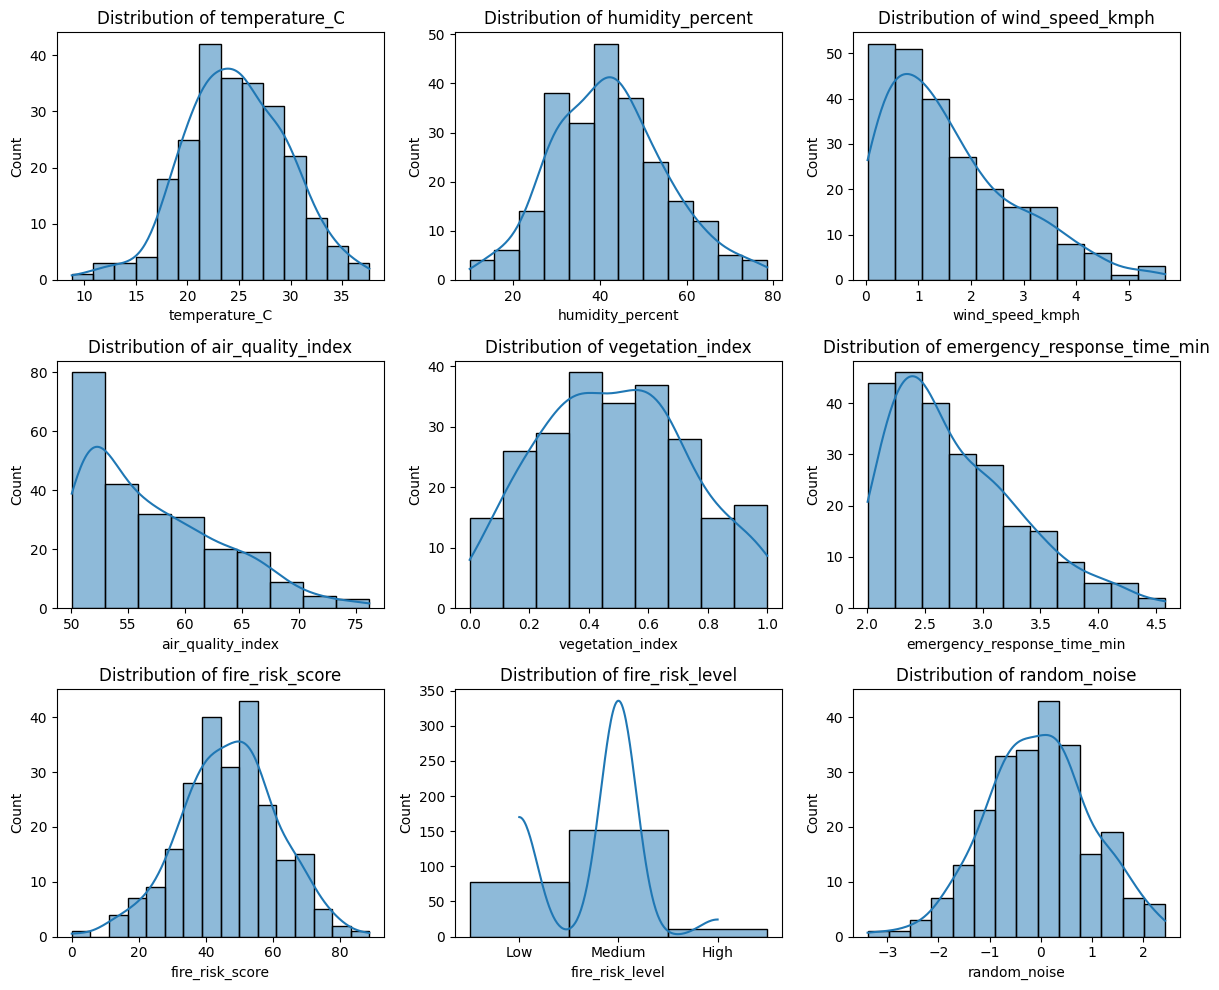

In [6]:
plt.figure(figsize=(12, 10))

for i, col in enumerate([
    'temperature_C','humidity_percent','wind_speed_kmph',
    'air_quality_index','vegetation_index','emergency_response_time_min',
    'fire_risk_score','fire_risk_level','random_noise'
]):
    plt.subplot(3, 3, i+1)   
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

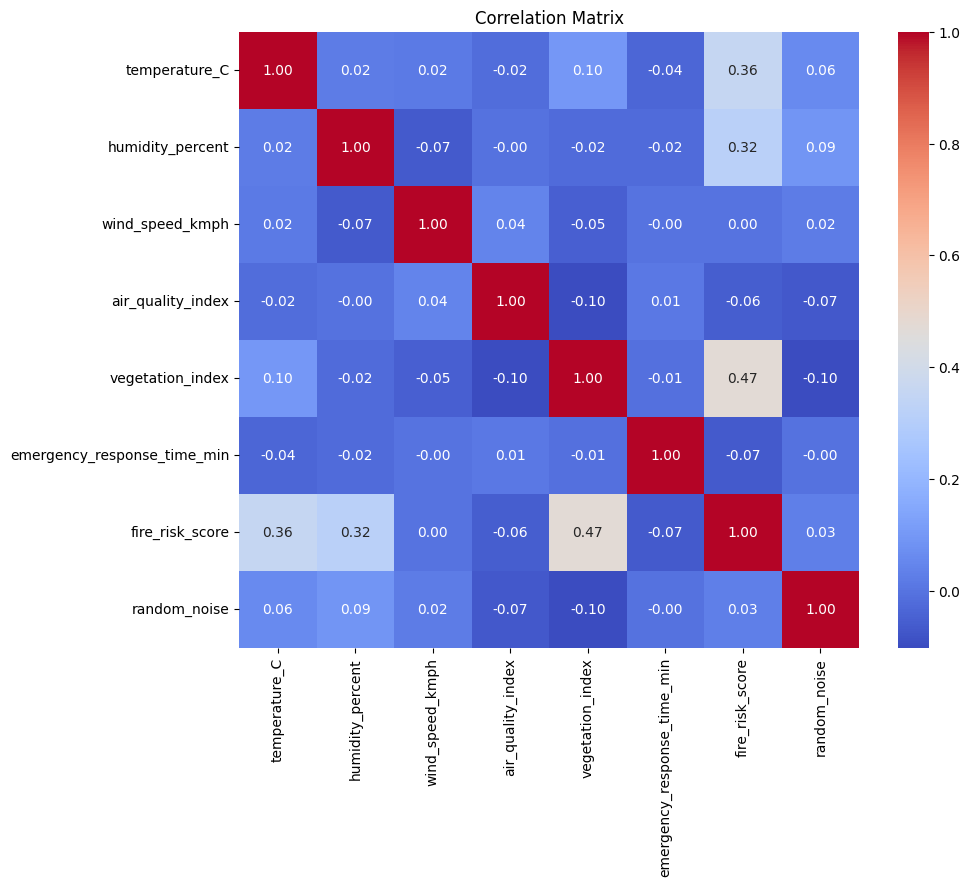

In [22]:
plt.figure(figsize=(10, 8))
corr_matrix = data.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10})
plt.title('Correlation Matrix')
plt.show()

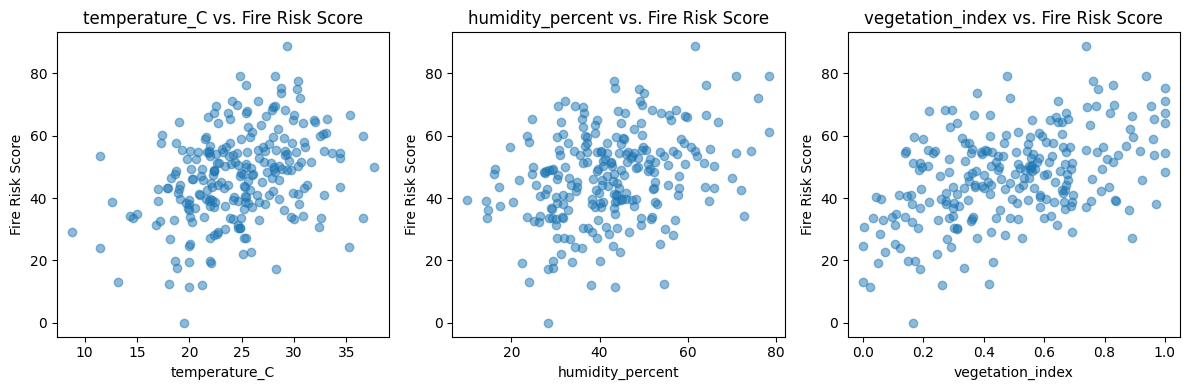

In [38]:

plt.figure(figsize=(12, 4))
for i, col in enumerate(['temperature_C', 'humidity_percent', 'vegetation_index'], 1):
    plt.subplot(1, 3, i)
    plt.scatter(data[col], data['fire_risk_score'], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('Fire Risk Score')
    plt.title(f'{col} vs. Fire Risk Score')
plt.tight_layout()
plt.show()


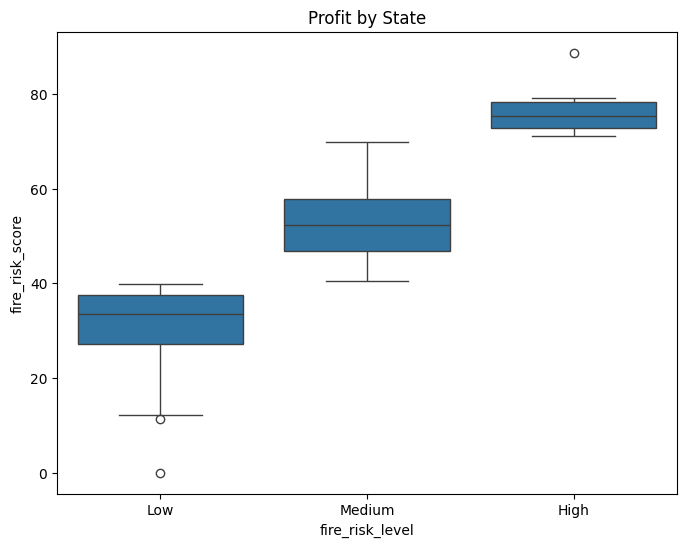

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='fire_risk_level', y='fire_risk_score', data=data)
plt.title('Profit by State')
plt.show()

In [ ]:
# Define features and target
X = data.drop('fire_risk_score', axis=1)
y = data['fire_risk_score']

In [20]:
X.head(15)

,temperature_C,humidity_percent,wind_speed_kmph,air_quality_index,vegetation_index,emergency_response_time_min,fire_risk_level,random_noise
0,19.939478,14.613031,3.309713,51.580079,0.882388,2.426881,Low,-1.349549
1,18.871172,45.988347,2.928750,54.831865,0.661799,3.573987,Medium,-0.042336
2,20.003489,10.000000,1.009550,62.969945,0.348045,2.022868,Low,-1.128474
3,17.908171,65.904458,3.521618,52.246847,0.400091,2.932591,Medium,0.113624
4,28.292721,30.808170,4.020409,52.858654,0.403075,2.334457,Medium,0.264644
5,34.430930,34.859282,0.349156,51.612857,0.299431,2.404051,Medium,0.378666
6,23.453955,17.429194,1.504313,50.824398,0.690014,3.457551,Low,0.350342
7,33.068556,39.037925,0.907069,53.213572,0.582191,2.421921,Medium,-0.323238
8,21.435771,31.395070,0.212860,50.327533,0.363285,2.543425,Low,-0.881434
9,32.463443,36.602817,0.542247,59.135846,0.591841,2.803179,Medium,0.615701


In [21]:
y


0      36.298824
1      41.477312
2      39.487676
3      43.355859
4      55.468398
         ...    
235    33.931698
236    42.633949
237    24.272872
238    27.089659
239    66.178001
Name: fire_risk_score, Length: 240, dtype: float64

In [26]:
#Simple Linear regression 

In [28]:
X = data[['vegetation_index']]   
y = data['fire_risk_score']

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [30]:
y_pred = model.predict(X)

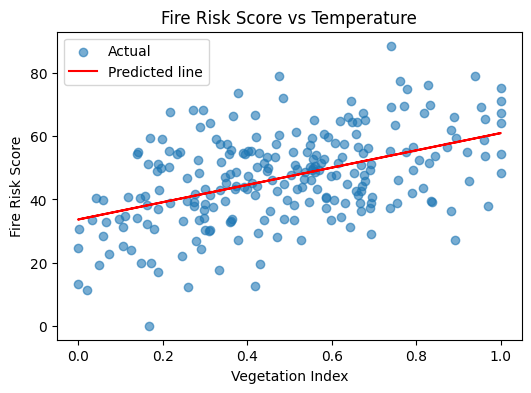

In [32]:
plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.6, label='Actual')
plt.plot(X, y_pred, color='red', label='Predicted line')
plt.xlabel('Vegetation Index')
plt.ylabel('Fire Risk Score')
plt.title('Fire Risk Score vs Temperature')
plt.legend()
plt.show()

In [39]:
w = model.coef_[0]
b = model.intercept_

print("w (slope):", w)
print("b (intercept):", b)

w (slope): 27.388163121080854
b (intercept): 33.65333924310576


In [62]:
#Multiple Linear Regression

feature_cols = [
    "temperature_C",
    "humidity_percent",
    "vegetation_index"
]
X = data[feature_cols]
y = data["fire_risk_score"]

In [63]:


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [64]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('reg', LinearRegression())])

In [65]:

y_val_pred = model.predict(X_val)

print("Validation R²:", r2_score(y_val, y_val_pred))
print("Validation MSE:", mean_squared_error(y_val, y_val_pred))


Validation R²: 0.2862435833724437
Validation MSE: 112.09915723627996


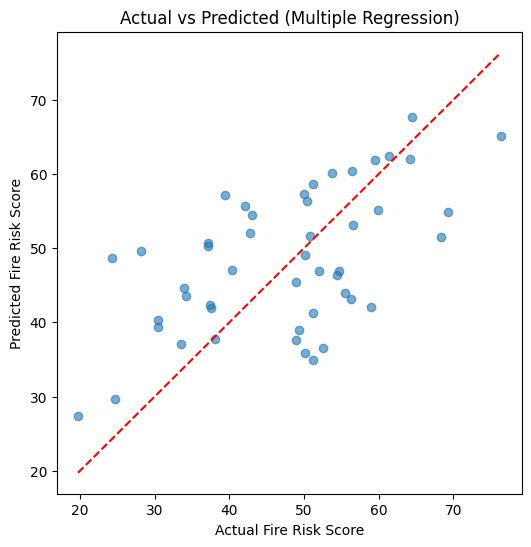

In [66]:
y_val_pred = model.predict(X_val)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--')
plt.xlabel("Actual Fire Risk Score")
plt.ylabel("Predicted Fire Risk Score")
plt.title("Actual vs Predicted (Multiple Regression)")
plt.show()


In [71]:

train = pd.read_csv("fire_risk_train.csv")
feature_cols = ["temperature_C", "humidity_percent", "vegetation_index"]
target_col = "fire_risk_score"
X_train = train[feature_cols]
y_train = train[target_col]

fire_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])
fire_pipeline.fit(X_train, y_train)

def predict_fire_risk_score(data: pd.DataFrame) -> pd.DataFrame:
    X_input = data[feature_cols]
    predictions = fire_pipeline.predict(X_input)
    result = data.copy()
    result["fire_risk_score_pred"] = predictions
    return result

example_data = pd.DataFrame({
    "temperature_C": [35, 28, 40],
    "humidity_percent": [30, 50, 20],
    "vegetation_index": [0.45, 0.6, 0.3]
})

predicted_result = predict_fire_risk_score(example_data)
print(predicted_result)

   temperature_C  humidity_percent  vegetation_index  fire_risk_score_pred
0             35                30              0.45             50.840920
1             28                50              0.60             55.560632
2             40                20              0.30             47.859089
